# Matrix Types and Sparsity

&nbsp;[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/themintlab/ExecutableEngineering/blob/main/chapters/linear_systems/matrix_properties/matrix_types_and_sparsity.ipynb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import executable_engineering as exe
except ImportError:
    %pip install -q executable_engineering
    import executable_engineering as exe

## Common Matrix Types

Before discussing advanced structural properties, here is a formal classification of fundamental matrix types encountered in numerical methods:

| Matrix Type | Property | Example $2 \times 2$ | 
|---|---|---|
| **Zero Matrix** | $a_{ij} = 0$ for all $i,j$ | $\begin{bmatrix} 0 & 0 \\ 0 & 0 \end{bmatrix}$ |
| **Identity Matrix** | $\mathbf{A}\mathbf{x} = \mathbf{x}$, ($a_{ii}=1, a_{ij}=0$) | $\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$ |
| **Diagonal** | $a_{ij} = 0$ for $i \neq j$ | $\begin{bmatrix} 2 & 0 \\ 0 & 3 \end{bmatrix}$ |
| **Upper Triangular** | $a_{ij} = 0$ for $i > j$ | $\begin{bmatrix} 2 & -1 \\ 0 & 3 \end{bmatrix}$ |
| **Lower Triangular** | $a_{ij} = 0$ for $i < j$ | $\begin{bmatrix} 2 & 0 \\ -1 & 3 \end{bmatrix}$ |
| **Symmetric** | $\mathbf{A} = \mathbf{A}^T$ | $\begin{bmatrix} 2 & -1 \\ -1 & 3 \end{bmatrix}$ |
| **Positive Definite** | $\mathbf{x}^T \mathbf{A} \mathbf{x} > 0$ for all $\mathbf{x} \neq 0$ | $\begin{bmatrix} 2 & -1 \\ -1 & 2 \end{bmatrix}$ |
| **Symmetric Positive Definite (SPD)** | $\mathbf{A} = \mathbf{A}^T$ and $\mathbf{x}^T \mathbf{A} \mathbf{x} > 0$ | $\begin{bmatrix} 2 & -1 \\ -1 & 2 \end{bmatrix}$ |
| **Orthogonal** | $\mathbf{A}^{-1} = \mathbf{A}^T$ | $\begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix}$ |

## What is Sparsity?

**Sparsity** refers to the fraction of non-zero elements in a matrix. 

Sparse matrices have a significant fraction of exactly $0$ elements. In real-world engineering problems (like discretizing differential equations or finite element analysis), matrices are often incredibly sparse.

Exploiting sparsity offers massive benefits:
* **Storage:** Instead of storing a massive 2D array full of zeros, we can store only the non-zero entries (and their locations), saving gigabytes of memory.
* **Computation:** Algorithms can be designed to ignore operations involving zeros, dramatically reducing execution time and computational complexity.

## Sparsity patterns and matrix

Sparsity patterns are condensly viewed as monochrome matricies filled in according to 0 or non-zero.

Example: A sparsity pattern from a finite element problem in 2D.

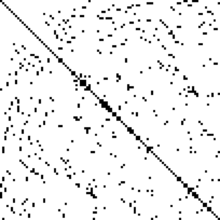

## Banded Matrices

**Banded matrices** only have non-zero elements running parallel to the main diagonal. The *bandwidth* describes how many parallel diagonal bands exist.

We have already seen how useful diagonal and triangular matrices are for controlling computational complexity (e.g. back-substitution). 

### Tridiagonal (Bandwidth 3)
A classic matrix structure in 1D physics problems (heat conduction, fluid flow) where every node only interacts with its immediate left and right neighbors.

In [ ]:
n = 10
A = np.zeros((n, n))
np.fill_diagonal(A, 2)         # Main diagonal
np.fill_diagonal(A[1:], -1)    # Upper diagonal
np.fill_diagonal(A[:, 1:], -1) # Lower diagonal

print("Tridiagonal Matrix:\n", A)

plt.spy(A)
plt.title("Sparsity Pattern (Tridiagonal)")
plt.show()

### Pentadiagonal (Bandwidth 5)
Commonly arises in 2D grid problems or higher-order finite difference methods.

In [ ]:
n = 10
A = np.zeros((n, n))
np.fill_diagonal(A, 2)         # Main diagonal
np.fill_diagonal(A[1:], -1)    # Upper diagonal
np.fill_diagonal(A[:, 1:], -1) # Lower diagonal
np.fill_diagonal(A[4:], -2)    # Far upper diagonal
np.fill_diagonal(A[:, 4:], -1) # Far lower diagonal

plt.spy(A)
plt.title("Sparsity Pattern (Pentadiagonal)")
plt.show()

## Block Matrices

Sometimes, a large sparse matrix can be logically partitioned into smaller sub-matrices, called **blocks**. 

$$
\mathbf{M} = \begin{bmatrix}
2 & -1 & 0 & | & 1 & 0 & 0 \\
-1 & 2 & -1 & | & 0 & 1 & 0 \\
0 & -1 & 2 & | & 0 & 0 & 1 \\
--&--&--&|&--&--&-- \\
1 & 0 & 0 & | & 2 & -1 & 0 \\
0 & 1 & 0 & | & -1 & 2 & -1 \\
0 & 0 & 1 & | & 0 & -1 & 2
\end{bmatrix} = \begin{bmatrix} \mathbf{A} & \mathbf{B} \\ \mathbf{C} & \mathbf{D} \end{bmatrix}
$$

This situation arises constantly in multi-physics applications (e.g., modeling Temperature and Pressure fields simultaneously). 

Instead of solving the massive matrix as a whole (**monolithic** solution), we can solve the blocks individually (**operator splitting** or **segregated solving**).

### Solving Block Matrices

Because the cost of matrix inversion scales as $\mathcal{O}(n^3)$, breaking a $2n \times 2n$ system into two $n \times n$ blocks is a massive computational savings!

For a block diagonal matrix (where off-diagonal blocks $\mathbf{B} = \mathbf{C} = \mathbf{0}$), the inverse is completely trivial:

$$
\begin{bmatrix}
\mathbf{A} & \mathbf{0} \\
\mathbf{0} & \mathbf{D}
\end{bmatrix}^{-1} = \begin{bmatrix}
\mathbf{A}^{-1} & \mathbf{0} \\
\mathbf{0} & \mathbf{D}^{-1}
\end{bmatrix}
$$